## RAG Agent

In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
from langchain_core.documents.base import Document
from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import Chroma

embedding_function = OpenAIEmbeddings()

docs = [
    Document(
        page_content="Bella Vista is owned by Antonio Rossi, a renowned chef with over 20 years of experience in the culinary industry. He started Bella Vista to bring authentic Italian flavors to the community.",
        metadata={"source": "owner.txt"},
    ),
    Document(
        page_content="Bella Vista offers a range of dishes with prices that cater to various budgets. Appetizers start at $8, main courses range from $15 to $35, and desserts are priced between $6 and $12.",
        metadata={"source": "dishes.txt"},
    ),
    Document(
        page_content="Bella Vista is open from Monday to Sunday. Weekday hours are 11:00 AM to 10:00 PM, while weekend hours are extended from 11:00 AM to 11:00 PM.",
        metadata={"source": "restaurant_info.txt"},
    ),
    Document(
        page_content="Bella Vista offers a variety of menus including a lunch menu, dinner menu, and a special weekend brunch menu. The lunch menu features light Italian fare, the dinner menu offers a more extensive selection of traditional and contemporary dishes, and the brunch menu includes both classic breakfast items and Italian specialties.",
        metadata={"source": "restaurant_info.txt"},
    ),
]

db = Chroma.from_documents(docs, embedding_function)

In [3]:
retriever = db.as_retriever(search_kwargs={"k": 4})

In [4]:
from langchain_classic import hub
from langchain_openai import ChatOpenAI

prompt = hub.pull("rlm/rag-prompt") # use hub to pull RAG-prompt

llm = ChatOpenAI(model="gpt-4o-mini")

def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)


rag_chain = prompt | llm

## Create RAG Agent using LangGraph

In [6]:
from typing import Annotated, Literal, TypedDict
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage
from langchain_core.documents import Document

class AgentState(TypedDict):
    messages: list[BaseMessage]
    documents: list[Document]
    on_topic: str



In [9]:
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate

class GradeQuestion(BaseModel):
    """Boolean value to check whether a question is related to the resturant Bella Vista"""

    score: str = Field(
        description="Question is about restaurant? If yes -> 'Yes' if not -> 'No'"
    )

def question_classifier(state: AgentState):
    question = state["messages"][-1].content
    system = """You are a classifier that determines whether a user's question is about one of the following topics:
    
    1. Information about the owner of Bella Vista, which is Antonio Rossi.
    2. Prices of dishes at Bella Vista (restaurant).
    3. Opening hours of Bella Vista (restaurant).

    If the question IS about any of these topics, respond with 'Yes'. Otherwise, respond with 'No'.
    """

    grade_prompt = ChatPromptTemplate.from_messages(
        [
            ("system", system),
            ("human", "User question: {question}"),
        ]
    )

    llm = ChatOpenAI(model="gpt-4o-mini")
    structured_llm = llm.with_structured_output(GradeQuestion)
    grader_llm = grade_prompt | structured_llm
    result = grader_llm.invoke({"question": question})
    state["on_topic"] = result.score
    return state



In [10]:
def on_topic_router(state):
    on_topic = state["on_topic"]
    if on_topic.lower() == "yes":
        return "on_topic"
    return "off_topic"

def retrieve(state):
    question = state["messages"][-1].content
    documents = retriever.invoke(question)
    state["documents"] = documents
    return state

def generate_answer(state):
    question = state["messages"][-1].content
    documents = state["documents"]
    generation = rag_chain.invoke({"context": documents, "question": question})
    state["messages"].append(generation)
    return state

def off_topic_response(state: AgentState):
    state["messages"].append(AIMessage(content="I con't respond to that!"))
    return state
    

In [11]:
from langgraph.graph import StateGraph, END

workflow = StateGraph(AgentState)

workflow.add_node("topic_decision", question_classifier)
workflow.add_node("off_topic_response", off_topic_response)
workflow.add_node("retrieve", retrieve)
workflow.add_node("generate_answer", generate_answer)

workflow.add_conditional_edges(
    "topic_decision",
    on_topic_router,
    {
        "on_topic": "retrieve",
        "off_topic": "off_topic_response"
    },
)

workflow.add_edge("retrieve", "generate_answer")
workflow.add_edge("generate_answer", END)
workflow.add_edge("off_topic_response", END)

workflow.set_entry_point("topic_decision")
graph = workflow.compile()

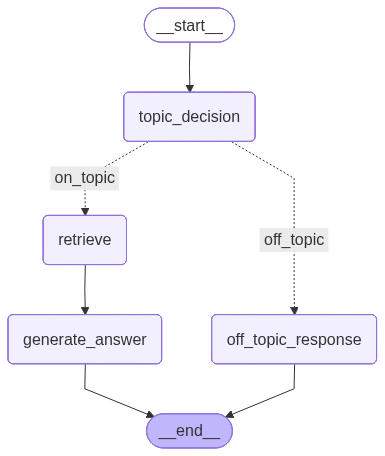

In [12]:
from IPython.display import display, Image
from langchain_core.runnables.graph import MermaidDrawMethod

display(
    Image(
        graph.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API
        )
    )
)

In [14]:
graph.invoke(input={"messages": [HumanMessage(content="When does the bella vista restaurant open?")]})

{'messages': [HumanMessage(content='When does the bella vista restaurant open?', additional_kwargs={}, response_metadata={}),
  AIMessage(content='Bella Vista is open from Monday to Sunday, with weekday hours from 11:00 AM to 10:00 PM and extended hours on weekends from 11:00 AM to 11:00 PM.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 42, 'prompt_tokens': 305, 'total_tokens': 347, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_83e2dd34fc', 'id': 'chatcmpl-DWmLfAFjr11bwHVgoY7PNQ64yDskV', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--999b729d-f3a9-497e-b2ce-9d12a1f0563e-0', usage_metadata={'input_tokens': 305, 'output_tokens': 42, 'total_tokens': 347, '

In [15]:
graph.invoke(input={"messages": [HumanMessage(content="What is artificial intelligence?")]})

{'messages': [HumanMessage(content='What is artificial intelligence?', additional_kwargs={}, response_metadata={}),
  AIMessage(content="I con't respond to that!", additional_kwargs={}, response_metadata={})],
 'on_topic': 'No'}

## Retrieval with Tools

In [19]:
from langchain_core.tools import create_retriever_tool
from langchain_core.tools import tool

retriever_tool = create_retriever_tool(
    retriever,
    "retriever_tool",
    "Information related to Pricing, Opening hours of the owner of the restaurant Bella Vista",
)

@tool
def off_topic():
    """Catch all Questions NOT related to Pricing, Opening hours of the owner of the restaurant Bella Vista"""
    return "Forbidden - do not respond to the user"

tools = [retriever_tool, off_topic ]

In [20]:
from typing import Sequence, TypedDict
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages

class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

In [21]:
from langchain_core.messages import HumanMessage
from langchain_openai import ChatOpenAI

def agent(state):
    messages = state["messages"]
    model = ChatOpenAI()
    model = model.bind_tools(tools)
    response = model.invoke(messages)
    return {"messages": [response]}

def should_continue(state) -> Literal["tools", END]:
    messages = state["messages"]
    last_message = messages[-1]
    if last_message.tool_calls:
        return "tools"
    return END

In [22]:
from langgraph.graph import END, StateGraph, START
from langgraph.prebuilt import ToolNode

In [23]:
workflow = StateGraph(AgentState)

workflow.add_node("agent", agent)

tool_node = ToolNode(tools)
workflow.add_node("tools", tool_node)
workflow.add_edge(START, "agent")
workflow.add_conditional_edges(
    "agent",
    should_continue,    
)

workflow.add_edge("tools", "agent")

graph = workflow.compile()


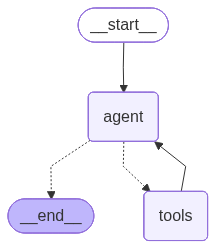

In [24]:
from IPython.display import display, Image
from langchain_core.runnables.graph import MermaidDrawMethod

display(
    Image(
        graph.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API
        )
    )
)

In [25]:
graph.invoke(input={"messages": [HumanMessage(content="How will the weather be tomorrow?")]})

{'messages': [HumanMessage(content='How will the weather be tomorrow?', additional_kwargs={}, response_metadata={}, id='549117de-4328-4e91-b3c0-7a4bd1af6095'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 100, 'total_tokens': 110, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-DWxYrJZeFVSU8Wvp51xIUk4ywotdp', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--78b9a26e-8d5c-4edb-b60e-e699a049a15f-0', tool_calls=[{'name': 'off_topic', 'args': {}, 'id': 'call_Q0szaS0IexEseZjhMnTXmT1j', 'type': 'tool_call'}], usage_metadata={'input_tokens': 100, 'output_tokens': 10, 'total_tokens': 110, 'input_token_

In [26]:
graph.invoke(input={"messages": [HumanMessage(content="When does the bella vista restaurant open?")]})

{'messages': [HumanMessage(content='When does the bella vista restaurant open?', additional_kwargs={}, response_metadata={}, id='fb851f6a-fa51-4217-a426-0a7d780b573a'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 101, 'total_tokens': 122, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-DWxZNAPR1le6zbTgY1BPxVSsaJ81y', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--b9bb94f1-758f-4bd8-936b-ab221d889272-0', tool_calls=[{'name': 'retriever_tool', 'args': {'query': 'opening hours of Bella Vista restaurant'}, 'id': 'call_aDodw3a8YkM2bpKqahAQoHzb', 'type': 'tool_call'}], usage_metadata={'input_token